In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/arunekambaram/anti-money-laundering-transaction-data/SAML-D.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/arunekambaram/anti-money-laundering-transaction-data/SAML-D.csv")
df.head()

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
0,10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits
1,10:35:20,2022-10-07,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,0,Normal_Fan_Out
2,10:35:20,2022-10-07,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Small_Fan_Out
3,10:35:21,2022-10-07,5376652437,9600420220,11895.00,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In
4,10:35:21,2022-10-07,9614186178,3803336972,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9504852 entries, 0 to 9504851
Data columns (total 12 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   Time                    object 
 1   Date                    object 
 2   Sender_account          int64  
 3   Receiver_account        int64  
 4   Amount                  float64
 5   Payment_currency        object 
 6   Received_currency       object 
 7   Sender_bank_location    object 
 8   Receiver_bank_location  object 
 9   Payment_type            object 
 10  Is_laundering           int64  
 11  Laundering_type         object 
dtypes: float64(1), int64(3), object(8)
memory usage: 870.2+ MB


In [4]:
df.describe().round(2)

,Sender_account,Receiver_account,Amount,Is_laundering
count,9.504852e+06,9.504852e+06,9504852.00,9504852.00
mean,5.006619e+09,5.006006e+09,8762.97,0.00
std,2.885814e+09,2.884763e+09,25614.95,0.03
min,9.018000e+03,9.018000e+03,3.73,0.00
25%,2.513133e+09,2.513219e+09,2143.69,0.00
50%,5.001017e+09,5.002572e+09,6113.72,0.00
75%,7.505051e+09,7.502397e+09,10458.46,0.00
max,9.999987e+09,9.999971e+09,12618498.40,1.00


In [5]:
print(f"shape data : {df.shape}")
print(f"total observation : {df.shape[0]}")
print(f"total columns: {df.shape[1]}")

shape data : (9504852, 12)
total observation : 9504852
total columns: 12


In [6]:
df.nunique()

Time                        86400
Date                          321
Sender_account             292715
Receiver_account           652266
Amount                    2314277
Payment_currency               13
Received_currency              13
Sender_bank_location           18
Receiver_bank_location         18
Payment_type                    7
Is_laundering                   2
Laundering_type                28
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

## Tidak ada missing values

In [8]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100
})

missing

,missing_count,missing_pct
Time,0,0.0
Date,0,0.0
Sender_account,0,0.0
Receiver_account,0,0.0
Amount,0,0.0
Payment_currency,0,0.0
Received_currency,0,0.0
Sender_bank_location,0,0.0
Receiver_bank_location,0,0.0
Payment_type,0,0.0


## Target class is very imbalanced

In [9]:
print(df["Is_laundering"].value_counts(), "\n\n")
print(df["Is_laundering"].value_counts(normalize=True))
print('\n\nTarget Class in very IMBALANCED')

Is_laundering
0    9494979
1       9873
Name: count, dtype: int64 


Is_laundering
0    0.998961
1    0.001039
Name: proportion, dtype: float64


Target Class in very IMBALANCED


## for each laundering type unique value, its either hundred percent laundering or not-laundering

In [10]:
display(pd.crosstab(
    df["Laundering_type"],
    df["Is_laundering"]
))

print("most likely Laundering_type is a label-derived information, hence should not be included in the model to prevent the model to \"peek\"")

Is_laundering,0,1
Laundering_type,,
Behavioural_Change_1,0,394
Behavioural_Change_2,0,345
Bipartite,0,383
Cash_Withdrawal,0,1334
Cycle,0,382
Deposit-Send,0,945
Fan_In,0,364
Fan_Out,0,237
Gather-Scatter,0,354


most likely Laundering_type is a label-derived information, hence should not be included in the model to prevent the model to "peek"


## there are no transaction below or equals 0

In [11]:
print(f"total amount of transaction below zero : {(df["Amount"] < 0).sum()}")
print(f"total amount of transaction equals zero : {(df["Amount"] == 0).sum()}")

total amount of transaction below zero : 0
total amount of transaction equals zero : 0


## UK Pounds is the most used Payment currency 

In [12]:
df["Payment_currency"].value_counts(dropna=False)

Payment_currency
UK pounds          9099293
Euro                117164
Turkish lira         27996
Swiss franc          27492
Dirham               27263
Pakistani rupee      27196
Naira                27143
US dollar            26061
Yen                  25562
Moroccan dirham      25395
Mexican Peso         24852
Albanian lek         24778
Indian rupee         24657
Name: count, dtype: int64

## UK Pounds is the most used Payment currency 

In [13]:
df["Received_currency"].value_counts(dropna=False)

Received_currency
UK pounds          8783655
Euro                231911
Pakistani rupee      45993
Yen                  45814
Moroccan dirham      45748
Albanian lek         45736
Mexican Peso         45255
Naira                45046
Indian rupee         43757
US dollar            43664
Swiss franc          42931
Dirham               42797
Turkish lira         42545
Name: count, dtype: int64

## most of the sender ID account is 10 digits, and there is just one sender account with 4 digits

In [14]:
df["Sender_account"].astype(str).str.len().value_counts()

Sender_account
10    8565935
9      827199
8      101436
7        9139
6         842
5         300
4           1
Name: count, dtype: int64

## most of the receiver ID account is 10 digits, and there is just one receiver account with 4 digits

In [15]:
df["Receiver_account"].astype(str).str.len().value_counts()

Receiver_account
10    8561959
9      842290
8       91517
7        8209
6         790
5          86
4           1
Name: count, dtype: int64

## Datetime format for all entries is appropriate

In [16]:
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

In [17]:
df["Date"].isna().sum()

np.int64(0)

In [18]:
df["Time"] = pd.to_datetime(
    df["Time"],
    format="%H:%M:%S",
    errors="coerce"
)

In [19]:
df["Time"].isna().sum()

np.int64(0)

In [20]:
df["Datetime"] = pd.to_datetime(
    df["Date"].dt.strftime("%Y-%m-%d") + " " +
    df["Time"].dt.strftime("%H:%M:%S"),
    errors="coerce"
)

## data starts from 2022-10-07 10:35:19 till 2023-08-23 10:57:12

In [21]:
print(df["Datetime"].min())
print(df["Datetime"].max())

2022-10-07 10:35:19
2023-08-23 10:57:12


## each entries in the data chronogically monotic inreacing

In [22]:
is_sorted = df["Datetime"].is_monotonic_increasing

print("Sorted:", is_sorted)

Sorted: True


## there's no self transfer, meaning no account transfer money to itself

In [23]:
self_transfer = df[
    df["Sender_account"] == df["Receiver_account"]
]

if len(self_transfer) == 0:
    print('there\'s no self-transfer')

there's no self-transfer


## the used payment currency is aligned with the currency of the country where the sender bank is located.

In [24]:
pd.crosstab(
    df["Sender_bank_location"],
    df["Payment_currency"]
)

Payment_currency,Albanian lek,Dirham,Euro,Indian rupee,Mexican Peso,Moroccan dirham,Naira,Pakistani rupee,Swiss franc,Turkish lira,UK pounds,US dollar,Yen
Sender_bank_location,,,,,,,,,,,,,
Albania,17491,16,13,9,17,12,15,16,14,14,5,10,16
Austria,14,20,17855,8,11,23,12,21,16,22,13,18,17
France,16,13,18486,11,20,17,25,11,28,13,33,14,15
Germany,23,14,19065,10,17,15,13,14,14,18,27,17,12
India,15,15,16,17407,15,15,17,11,22,18,21,11,13
Italy,14,15,18706,18,16,23,13,16,19,16,10,17,12
Japan,11,24,13,10,23,10,15,20,15,23,16,13,18275
Mexico,13,15,18,10,17493,15,11,8,15,15,11,13,25
Morocco,18,14,9,15,19,18254,6,10,15,21,17,20,19


## the used received currency is aligned with the currency of the country where the receiver bank is located.

In [25]:
pd.crosstab(
    df["Receiver_bank_location"],
    df["Received_currency"]
)

Received_currency,Albanian lek,Dirham,Euro,Indian rupee,Mexican Peso,Moroccan dirham,Naira,Pakistani rupee,Swiss franc,Turkish lira,UK pounds,US dollar,Yen
Receiver_bank_location,,,,,,,,,,,,,
Albania,38373,32,28,46,37,35,35,36,30,30,36,29,36
Austria,26,27,38461,40,22,28,27,34,31,36,42,31,39
France,33,32,38150,28,36,30,27,34,35,21,32,20,34
Germany,30,31,38167,43,19,34,38,28,34,21,35,21,39
India,35,39,26,36547,38,28,22,30,29,41,39,25,37
Italy,34,21,36175,27,31,35,22,32,28,22,35,24,31
Japan,38,35,37,43,36,28,23,26,31,27,24,32,38349
Mexico,26,32,33,28,38035,25,32,24,30,29,33,29,29
Morocco,36,30,29,40,32,38307,37,23,32,33,37,41,27


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

## target class distribution is very imbalanced, very few for laundering compared to non-laundering

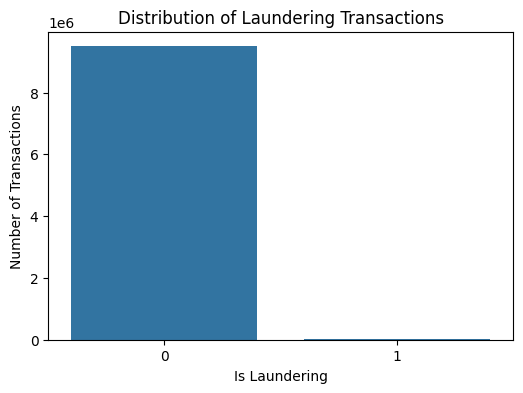

In [27]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Is_laundering"
)

plt.title("Distribution of Laundering Transactions")
plt.xlabel("Is Laundering")
plt.ylabel("Number of Transactions")

plt.show()

## the distribution for amount transaction is very right-skewed. applying log transformation may be useful

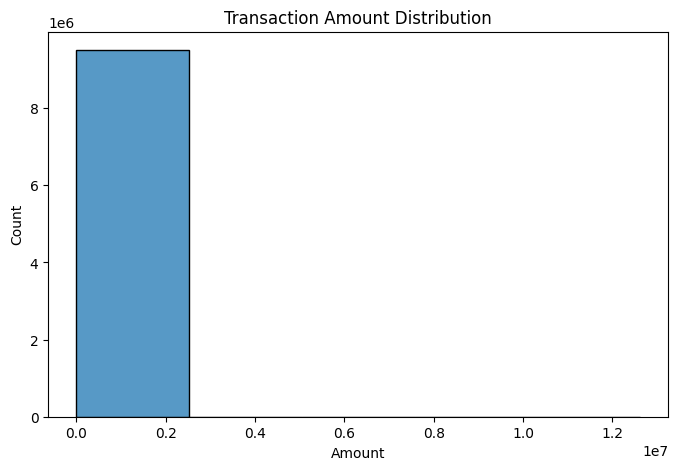

In [28]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Amount",
    bins=5
)

plt.title("Transaction Amount Distribution")
plt.show()

## distribution of log transaction amount

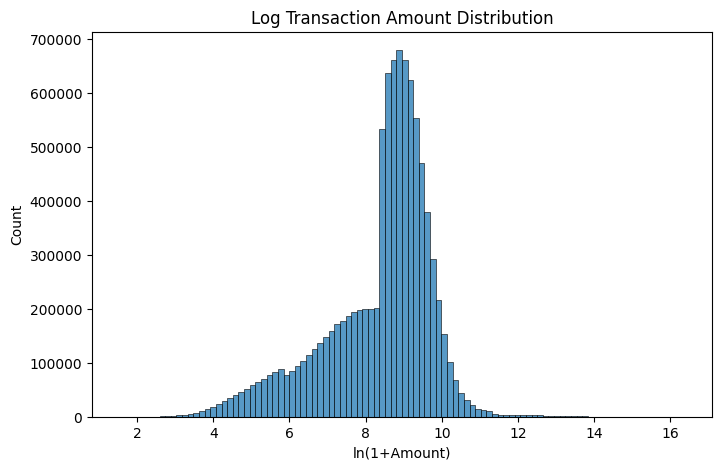

In [29]:
plt.figure(figsize=(8, 5))

sns.histplot(
    np.log1p(df["Amount"]),
    bins=100
)

plt.title("Log Transaction Amount Distribution")
plt.xlabel("ln(1+Amount)")
plt.show()

## 50% Data Utama Nyaris Identik: Baik transaksi normal maupun laundering, rentang 50% data utamanya berkumpul di kisaran nominal yang sama ($10^3$–$10^4$). Nilai tengah (median) keduanya pun berada di level yang sejajar.

## Outlier Menjadi Pembeda Utama: Pola pencucian uang baru terlihat jelas di area nilai ekstrem (outlier). Transaksi laundering memiliki ekor outlier yang melambung jauh lebih tinggi hingga menembus $10^7$, sementara transaksi normal sudah berhenti di kisaran $10^6$.

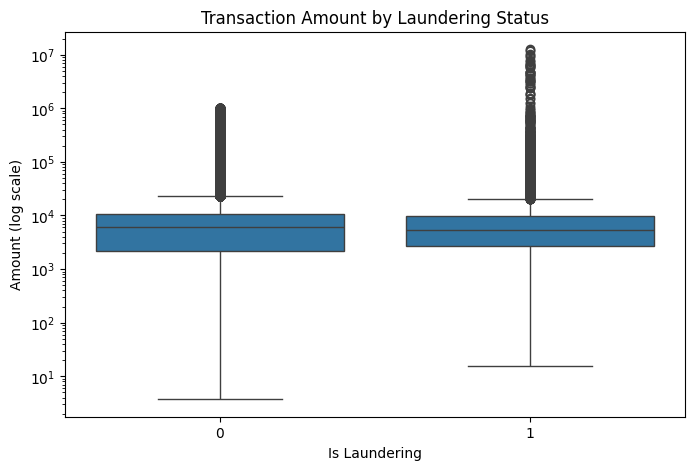

In [30]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Is_laundering",
    y="Amount"
)

plt.yscale("log")

plt.title("Transaction Amount by Laundering Status")
plt.xlabel("Is Laundering")
plt.ylabel("Amount (log scale)")

plt.show()

In [31]:
amount_summary = (
    df.groupby("Is_laundering")["Amount"]
      .agg([
          "count",
          "mean",
          "median",
          "std",
          "min",
          "max"
      ])
)

amount_summary

,count,mean,median,std,min,max
Is_laundering,,,,,,
0,9494979,8729.875874,6114.63,21750.032069,3.73,999962.19
1,9873,40587.666906,5322.79,419181.131445,15.82,12618498.40


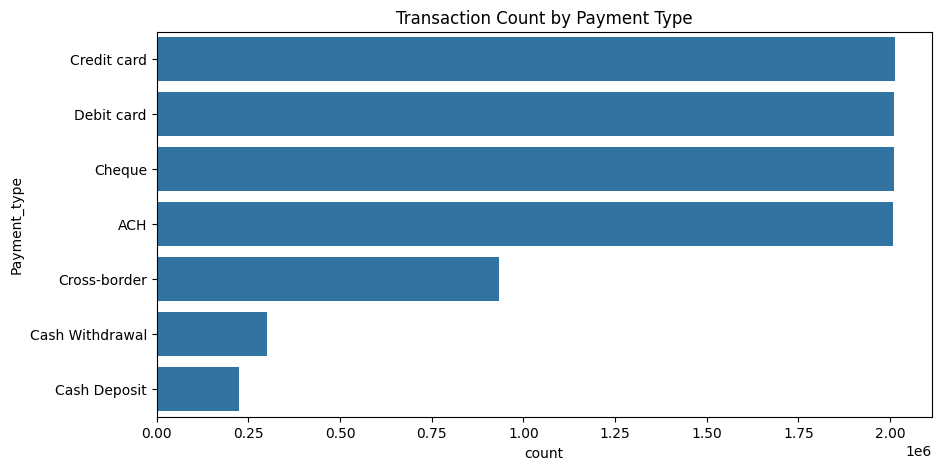

In [32]:
categorical_cols = [
    "Payment_currency",
    "Received_currency",
    "Sender_bank_location",
    "Receiver_bank_location",
    "Payment_type"
]

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    y="Payment_type",
    order=df["Payment_type"].value_counts().index
)

plt.title("Transaction Count by Payment Type")
plt.show()

In [33]:
payment_laundering_rate = (
    df.groupby("Payment_type")["Is_laundering"]
      .agg(["count", "mean"])
      .sort_values("mean", ascending=False)
)

payment_laundering_rate["laundering_rate_pct"] = (
    payment_laundering_rate["mean"] * 100
)

payment_laundering_rate

,count,mean,laundering_rate_pct
Payment_type,,,
Cash Deposit,225206,0.006239,0.623873
Cash Withdrawal,300477,0.004440,0.443961
Cross-border,933931,0.002814,0.281391
ACH,2008807,0.000577,0.057696
Credit card,2012909,0.000564,0.056436
Debit card,2012103,0.000559,0.055862
Cheque,2011419,0.000540,0.054041


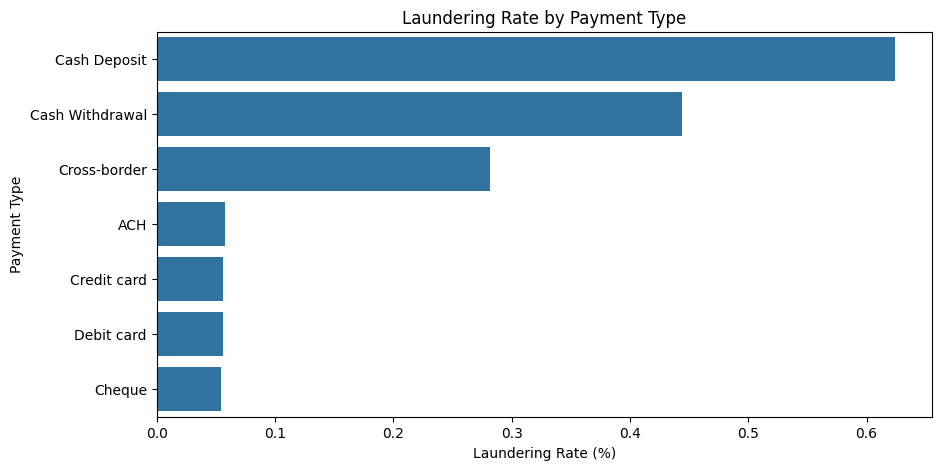

In [34]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=payment_laundering_rate.reset_index(),
    x="laundering_rate_pct",
    y="Payment_type"
)

plt.xlabel("Laundering Rate (%)")
plt.ylabel("Payment Type")
plt.title("Laundering Rate by Payment Type")

plt.show()


In [35]:
currency_summary = (
    df.groupby("Payment_currency")["Is_laundering"]
      .agg(["count", "mean"])
      .sort_values("mean", ascending=False)
)

currency_summary["laundering_rate_pct"] = (
    currency_summary["mean"] * 100
)

currency_summary

,count,mean,laundering_rate_pct
Payment_currency,,,
Moroccan dirham,25395,0.003544,0.354400
Dirham,27263,0.003264,0.326450
Swiss franc,27492,0.002983,0.298269
Indian rupee,24657,0.002758,0.275784
Mexican Peso,24852,0.002736,0.273620
Turkish lira,27996,0.002608,0.260752
Albanian lek,24778,0.002583,0.258294
Yen,25562,0.002543,0.254284
US dollar,26061,0.002302,0.230229


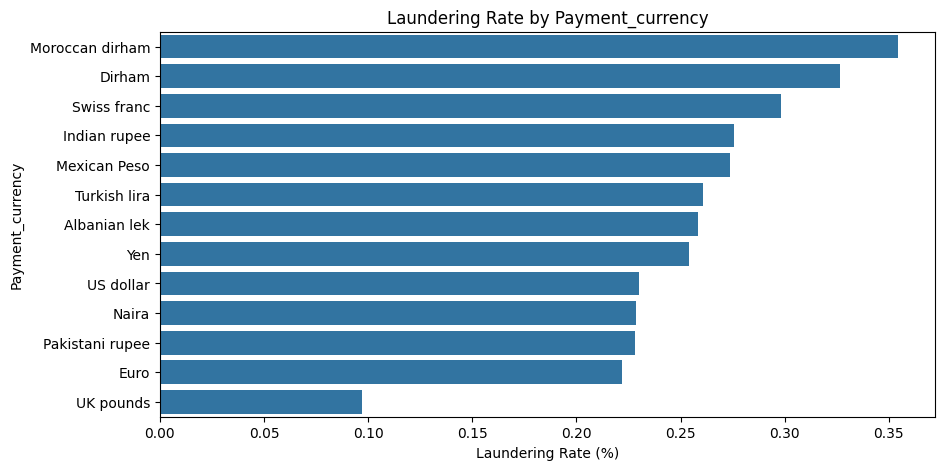

In [36]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=currency_summary.reset_index(),
    x="laundering_rate_pct",
    y="Payment_currency"
)

plt.xlabel("Laundering Rate (%)")
plt.ylabel("Payment_currency")
plt.title("Laundering Rate by Payment_currency")

plt.show()


In [37]:
received_currency_summary = (
    df.groupby("Received_currency")["Is_laundering"]
      .agg(["count", "mean"])
      .sort_values("mean", ascending=False)
)

received_currency_summary["laundering_rate_pct"] = (
    received_currency_summary["mean"] * 100
)

display(received_currency_summary)

,count,mean,laundering_rate_pct
Received_currency,,,
Naira,45046,0.006393,0.639346
Moroccan dirham,45748,0.006230,0.622978
Albanian lek,45736,0.005729,0.572853
Dirham,42797,0.005257,0.525738
Mexican Peso,45255,0.005193,0.519280
Turkish lira,42545,0.005124,0.512399
Pakistani rupee,45993,0.004435,0.443546
Indian rupee,43757,0.003931,0.393080
Euro,231911,0.003087,0.308739


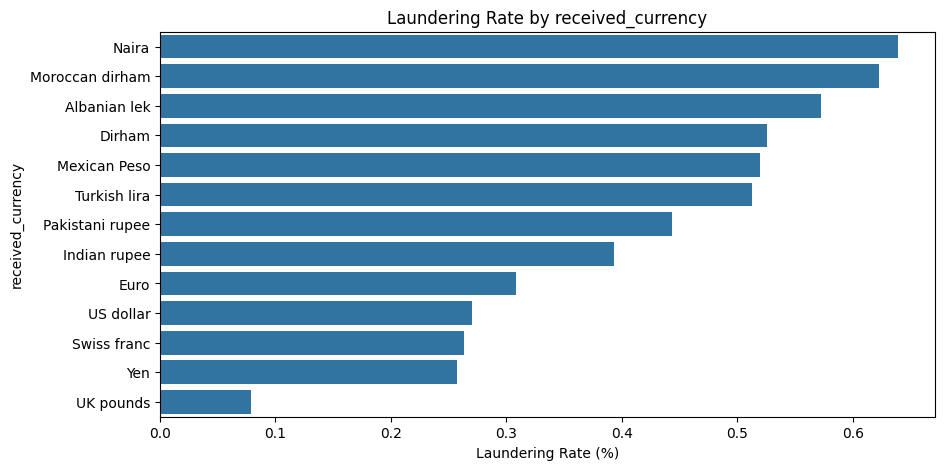

In [38]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=received_currency_summary.reset_index(),
    x="laundering_rate_pct",
    y="Received_currency"
)

plt.xlabel("Laundering Rate (%)")
plt.ylabel("received_currency")
plt.title("Laundering Rate by received_currency")

plt.show()


In [39]:
sender_country = (
    df.groupby("Sender_bank_location")["Is_laundering"]
      .agg(["count", "mean"])
      .sort_values("mean", ascending=False)
)

sender_country["laundering_rate_pct"] = sender_country["mean"] * 100

display(sender_country)

,count,mean,laundering_rate_pct
Sender_bank_location,,,
Morocco,18437,0.002983,0.298313
Mexico,17662,0.002491,0.249122
Netherlands,16770,0.002445,0.244484
India,17596,0.002387,0.238691
Italy,18895,0.002382,0.238158
Germany,19259,0.002233,0.223272
Austria,18050,0.002105,0.210526
Japan,18468,0.002058,0.205761
Switzerland,20503,0.002000,0.199971


In [40]:
receiver_country = (
    df.groupby("Receiver_bank_location")["Is_laundering"]
      .agg(["count", "mean"])
      .sort_values("mean", ascending=False)
)

receiver_country["laundering_rate_pct"] = (
    receiver_country["mean"] * 100
)

display(receiver_country)

,count,mean,laundering_rate_pct
Receiver_bank_location,,,
Nigeria,38272,0.006558,0.655832
Morocco,38704,0.006537,0.653679
Albania,38783,0.006059,0.605936
UAE,35897,0.005432,0.543221
Mexico,38385,0.005132,0.513221
Turkey,35586,0.004974,0.497387
Pakistan,38980,0.004336,0.433556
Netherlands,37314,0.003966,0.396634
Austria,38844,0.003965,0.396458


In [41]:
df["is_cross_border"] = (
    df["Sender_bank_location"]
    != df["Receiver_bank_location"]
).astype(int)

In [42]:
cross_border_summary = (
    df.groupby("is_cross_border")["Is_laundering"]
      .agg(["count", "mean"])
)

cross_border_summary["laundering_rate_pct"] = (
    cross_border_summary["mean"] * 100
)

display(cross_border_summary)

,count,mean,laundering_rate_pct
is_cross_border,,,
0,8570504,0.000797,0.079669
1,934348,0.003259,0.325896


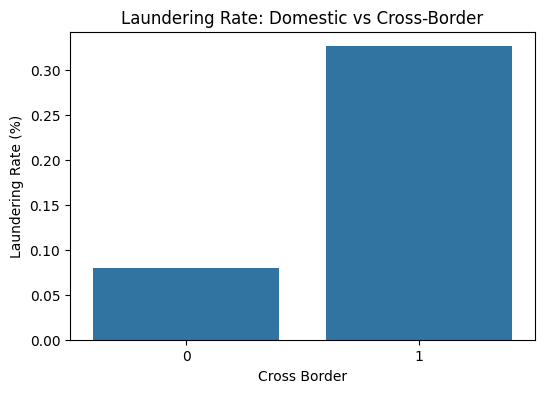

In [43]:
plt.figure(figsize=(6, 4))

sns.barplot(
    data=cross_border_summary.reset_index(),
    x="is_cross_border",
    y="laundering_rate_pct"
)

plt.xlabel("Cross Border")
plt.ylabel("Laundering Rate (%)")
plt.title("Laundering Rate: Domestic vs Cross-Border")

plt.show()

In [44]:
df["is_currency_conversion"] = (
    df["Payment_currency"]
    != df["Received_currency"]
).astype(int)

In [45]:
conversion_summary = (
    df.groupby("is_currency_conversion")["Is_laundering"]
      .agg(["count", "mean"])
)

conversion_summary["laundering_rate_pct"] = (
    conversion_summary["mean"] * 100
)

conversion_summary

,count,mean,laundering_rate_pct
is_currency_conversion,,,
0,8418990,0.000738,0.073833
1,1085862,0.003368,0.336783


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9504852 entries, 0 to 9504851
Data columns (total 15 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   Time                    datetime64[ns]
 1   Date                    datetime64[ns]
 2   Sender_account          int64         
 3   Receiver_account        int64         
 4   Amount                  float64       
 5   Payment_currency        object        
 6   Received_currency       object        
 7   Sender_bank_location    object        
 8   Receiver_bank_location  object        
 9   Payment_type            object        
 10  Is_laundering           int64         
 11  Laundering_type         object        
 12  Datetime                datetime64[ns]
 13  is_cross_border         int64         
 14  is_currency_conversion  int64         
dtypes: datetime64[ns](3), float64(1), int64(5), object(6)
memory usage: 1.1+ GB


In [47]:
df["hour"] = df["Datetime"].dt.hour
df["day_of_week"] = df["Datetime"].dt.dayofweek
df["date_only"] = df["Datetime"].dt.date
df['day_of_month'] = df['Datetime'].dt.day

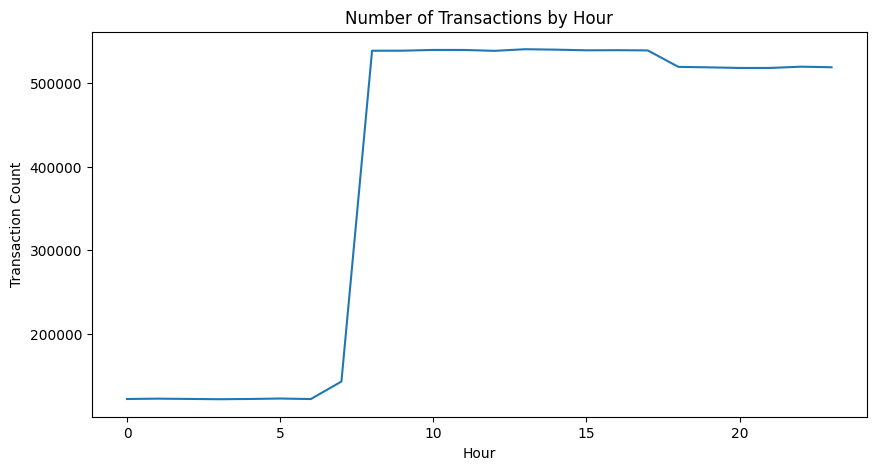

In [48]:
hourly_transactions = (
    df.groupby("hour")
      .size()
)

plt.figure(figsize=(10, 5))

hourly_transactions.plot()

plt.title("Number of Transactions by Hour")
plt.xlabel("Hour")
plt.ylabel("Transaction Count")

plt.show()

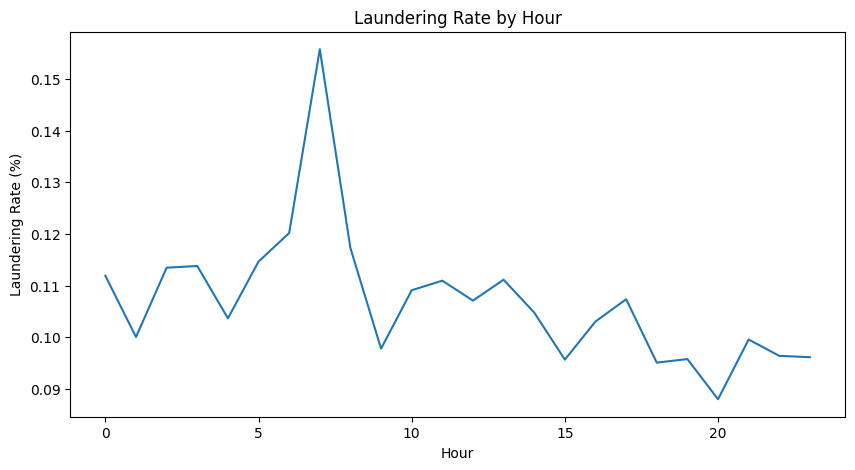



Hour with highest laudering rate = 7


In [49]:
hourly_laundering = (
    df.groupby("hour")["Is_laundering"]
      .mean()
      .mul(100)
)

plt.figure(figsize=(10, 5))

hourly_laundering.plot()

plt.title("Laundering Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Laundering Rate (%)")

plt.show()

print(f"\n\nHour with highest laudering rate = {hourly_laundering.idxmax()}")

In [50]:
day_summary = (
    df.groupby("day_of_week")["Is_laundering"]
      .agg(["count", "mean"])
)

day_summary["laundering_rate_pct"] = (
    day_summary["mean"] * 100
)

day_summary

,count,mean,laundering_rate_pct
day_of_week,,,
0,1389246,0.001060,0.105957
1,1369343,0.001040,0.103991
2,1366034,0.001049,0.104902
3,1350706,0.001077,0.107721
4,1369872,0.001083,0.108258
5,1336623,0.000980,0.098008
6,1323028,0.000980,0.097957


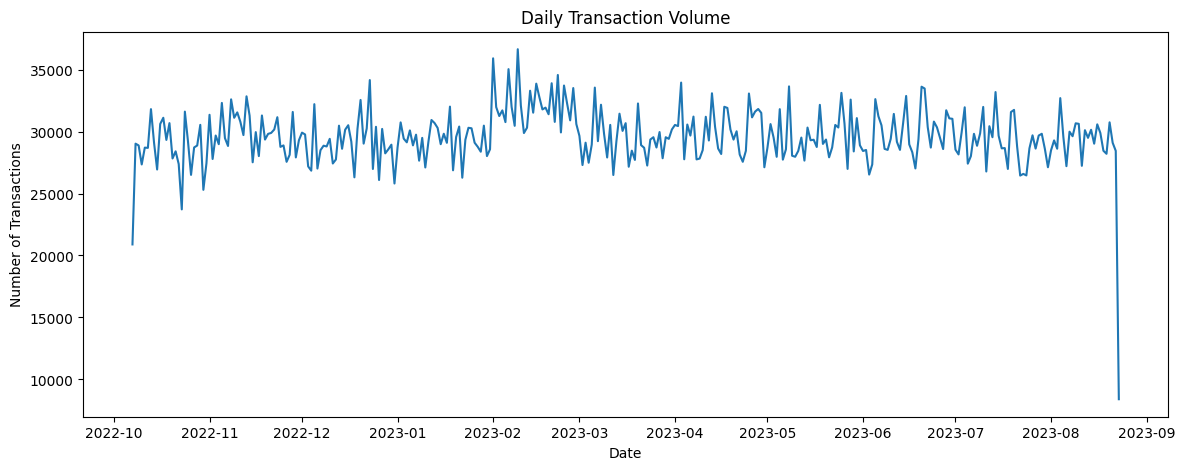

In [51]:
daily_transactions = (
    df.groupby("date_only")
      .size()
)

plt.figure(figsize=(14, 5))

daily_transactions.plot()

plt.title("Daily Transaction Volume")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")

plt.show()

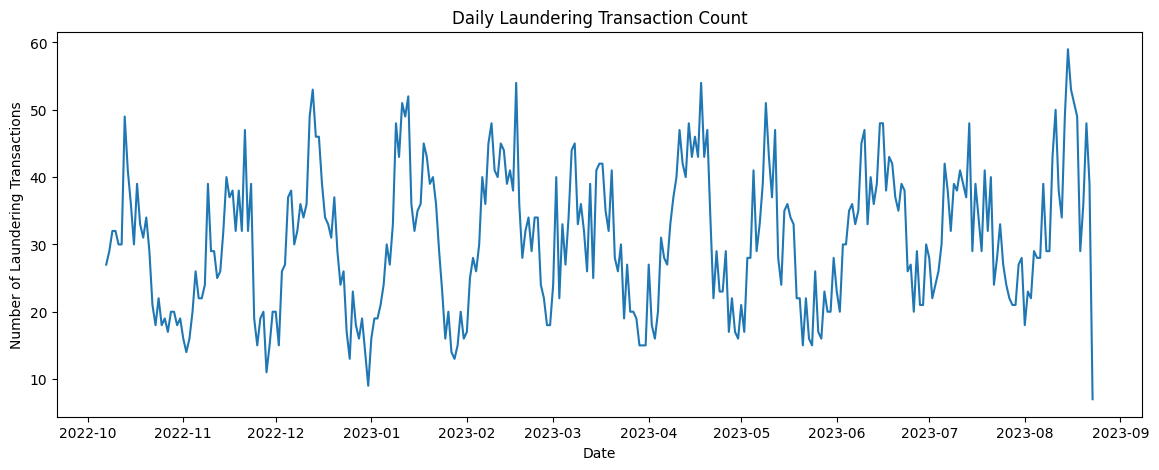

THERE'S MONTHLY SEASONAL PATTERNS


In [52]:
daily_laundering = (
    df.groupby("date_only")["Is_laundering"]
      .sum()
)

plt.figure(figsize=(14, 5))

daily_laundering.plot()

plt.title("Daily Laundering Transaction Count")
plt.xlabel("Date")
plt.ylabel("Number of Laundering Transactions")

plt.show()

print("THERE'S MONTHLY SEASONAL PATTERNS")

In [53]:
df.columns

Index(['Time', 'Date', 'Sender_account', 'Receiver_account', 'Amount',
       'Payment_currency', 'Received_currency', 'Sender_bank_location',
       'Receiver_bank_location', 'Payment_type', 'Is_laundering',
       'Laundering_type', 'Datetime', 'is_cross_border',
       'is_currency_conversion', 'hour', 'day_of_week', 'date_only',
       'day_of_month'],
      dtype='object')

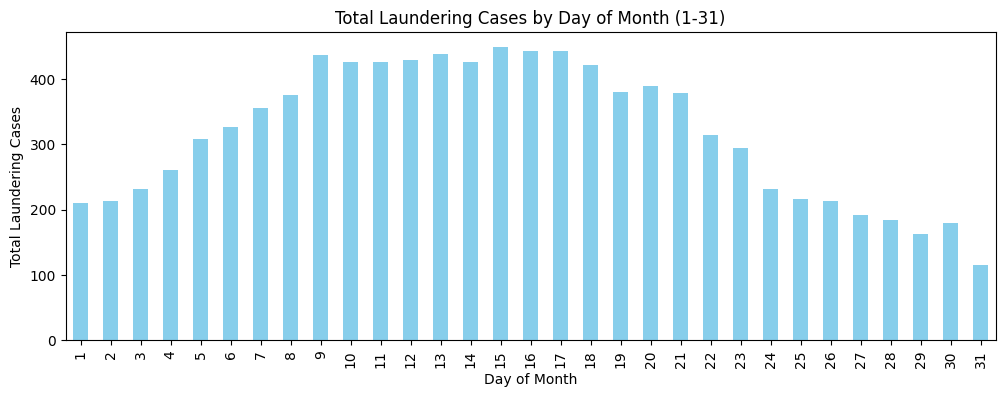

In [54]:
monthly_pattern = df.groupby('day_of_month')['Is_laundering'].sum()


plt.figure(figsize=(12, 4))
monthly_pattern.plot(kind='bar', color='skyblue')
plt.title("Total Laundering Cases by Day of Month (1-31)")
plt.xlabel("Day of Month")
plt.ylabel("Total Laundering Cases")
plt.show()

In [55]:
print(
    "Unique senders:",
    df["Sender_account"].nunique()
)

print(
    "Unique receivers:",
    df["Receiver_account"].nunique()
)

print(
    "Unique accounts:",
    pd.unique(
        df[["Sender_account", "Receiver_account"]].values.ravel()
    ).size
)

Unique senders: 292715
Unique receivers: 652266
Unique accounts: 855460


In [56]:
sender_activity = (
    df.groupby("Sender_account")
      .agg(
          transaction_count=("Sender_account", "size"),
          total_amount=("Amount", "sum"),
          avg_amount=("Amount", "mean"),
          unique_receivers=("Receiver_account", "nunique")
      )
      .sort_values("transaction_count", ascending=False)
)

sender_activity.head(20)

,transaction_count,total_amount,avg_amount,unique_receivers
Sender_account,,,,
4808614002,754,4450195.04,5902.115438,25
2938210715,753,4052721.72,5382.100558,23
5579295130,751,4570856.24,6086.359840,25
2357599526,749,5688771.44,7595.155461,25
3831533348,749,5210276.12,6956.309907,55
798082205,743,5053281.51,6801.186420,58
9810335545,742,3908506.89,5267.529501,23
8600542721,738,2123264.63,2877.052344,25
8913863501,736,3140740.94,4267.311060,24


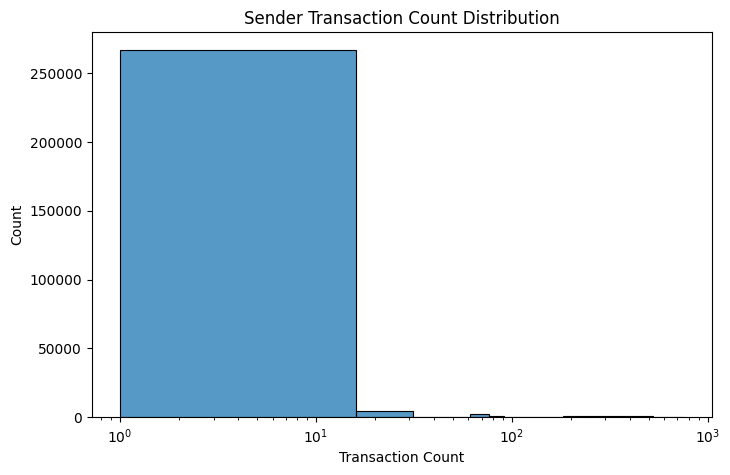

In [57]:
plt.figure(figsize=(8, 5))

sns.histplot(
    sender_activity["transaction_count"],
    bins=50
)

plt.xscale("log")

plt.title("Sender Transaction Count Distribution")
plt.xlabel("Transaction Count")
plt.show()

In [58]:
receiver_activity = (
    df.groupby("Receiver_account")
      .agg(
          transaction_count=("Receiver_account", "size"),
          total_amount=("Amount", "sum"),
          avg_amount=("Amount", "mean"),
          unique_senders=("Sender_account", "nunique")
      )
      .sort_values("transaction_count", ascending=False)
)

display(receiver_activity.head(20))

,transaction_count,total_amount,avg_amount,unique_senders
Receiver_account,,,,
8600542721,751,4182791.24,5569.628815,17
2938210715,745,4997841.44,6708.512000,17
5460360634,740,4141297.11,5596.347446,17
5579295130,739,3363836.68,4551.876428,17
4808614002,737,2943969.44,3994.531126,17
4724445469,736,5258861.76,7145.192609,17
3747015869,734,3092588.99,4213.336499,17
9544431251,734,4836645.33,6589.435054,17
4924631375,734,2766504.27,3769.079387,17


In [59]:
fan_out = (
    df.groupby("Sender_account")["Receiver_account"]
      .nunique()
      .sort_values(ascending=False)
)

display(fan_out.head(20))

Sender_account
5791275590    60
3656038300    59
8180422959    59
3566232777    59
4623242164    59
8035399972    59
2822872306    59
9719585962    59
7470300488    59
1542389688    59
5097207315    59
4275432794    59
7288416542    59
108321125     59
8904484086    59
2527100295    58
8859211680    58
6092699679    58
2019695418    58
6035815939    58
Name: Receiver_account, dtype: int64

In [75]:
sender_laundering = (
    df.groupby("Sender_account")["Is_laundering"]
      .mean()
)

sender_network = pd.DataFrame({
    "unique_receivers": fan_out,
    "laundering_rate": sender_laundering
}).dropna()

suspicious_senders = (
    sender_network[sender_network["laundering_rate"] > 0]
    .sort_values(by=["laundering_rate", "unique_receivers"], ascending=[False, False])
)

display(suspicious_senders.head(20))
print(f"total suspicious sender with laudering rate > 0 : {len(suspicious_senders)}")

,unique_receivers,laundering_rate
Sender_account,,
5917350547,9,1.000000
2247370907,2,0.958333
4159678387,3,0.925000
2488893433,4,0.896552
5008453588,4,0.892857
3864360347,4,0.869565
4220180108,7,0.857143
1865451606,4,0.857143
5262095561,4,0.838710


total suspicious sender with laudering rate > 0 : 4950


In [61]:
# 1. Hitung fan-in (jumlah pengirim unik untuk setiap penerima)
fan_in = df.groupby("Receiver_account")["Sender_account"].nunique()

# 2. Hitung tingkat laundering untuk setiap penerima
receiver_laundering = df.groupby("Receiver_account")["Is_laundering"].mean()

# 3. Gabungkan ke dalam DataFrame receiver_network
receiver_network = pd.DataFrame({
    "unique_senders": fan_in,
    "laundering_rate": receiver_laundering
}).dropna()

# 4. Filter & tampilkan akun penerima yang terindikasi laundering (rate > 0)
suspicious_receivers = (
    receiver_network[receiver_network["laundering_rate"] > 0]
    .sort_values(by=["laundering_rate", "unique_senders"], ascending=[False, False])
)

display(suspicious_receivers.head(20))
print(f"total suspicious receiver with laudering rate > 0 : {len(suspicious_receivers)}")

,unique_senders,laundering_rate
Receiver_account,,
3282818329,23,1.0
7748494288,23,1.0
2058371508,12,1.0
6420523836,6,1.0
6519798386,6,1.0
8060121943,6,1.0
864151511,5,1.0
5190940865,4,1.0
5850126964,4,1.0


total suspicious receiver with laudering rate > 0 : 4074


In [64]:
unique_edges = (
    df[["Sender_account", "Receiver_account"]]
    .drop_duplicates()
)

print("Unique transaction edges:", len(unique_edges))

Unique transaction edges: 887497


In [65]:
edge_frequency = (
    df.groupby(
        ["Sender_account", "Receiver_account"]
    )
    .size()
    .sort_values(ascending=False)
)

display(edge_frequency.head(20))

Sender_account  Receiver_account
5032745881      5216531044          84
1931246840      2078538423          84
1337920692      3232244126          83
7234973076      6408343900          83
8117397180      3922554569          83
6369359732      5216531044          82
5992045283      2766094282          82
7641911870      2086374242          82
417590431       4290035884          82
2657142247      9593308569          82
8343566005      396374472           82
7711289254      4594125641          82
8972953969      3453718277          82
7352274760      4613325765          82
9415220356      8824829352          82
9434455819      9431352038          82
135431080       4784991805          81
5173333833      1750168908          81
2481974875      9810335545          81
274239431       7953897873          81
dtype: int64

In [66]:
df["Laundering_type"].value_counts()

Laundering_type
Normal_Small_Fan_Out      3477717
Normal_Fan_Out            2302220
Normal_Fan_In             2104285
Normal_Group               528351
Normal_Cash_Withdrawal     305031
Normal_Cash_Deposits       223801
Normal_Periodical          210526
Normal_Plus_Mutual         155041
Normal_Mutual              125335
Normal_Foward               42031
Normal_single_large         20641
Structuring                  1870
Cash_Withdrawal              1334
Deposit-Send                  945
Smurfing                      932
Layered_Fan_In                656
Layered_Fan_Out               529
Stacked Bipartite             506
Behavioural_Change_1          394
Bipartite                     383
Cycle                         382
Fan_In                        364
Gather-Scatter                354
Behavioural_Change_2          345
Scatter-Gather                338
Single_large                  250
Fan_Out                       237
Over-Invoicing                 54
Name: count, dtype: int64

In [67]:
laundering_type_analysis = (
    df.groupby("Laundering_type")["Is_laundering"]
      .agg(["count", "mean"])
      .sort_values("mean", ascending=False)
)

laundering_type_analysis["laundering_rate_pct"] = (
    laundering_type_analysis["mean"] * 100
)

display(laundering_type_analysis)

,count,mean,laundering_rate_pct
Laundering_type,,,
Behavioural_Change_1,394,1.0,100.0
Behavioural_Change_2,345,1.0,100.0
Bipartite,383,1.0,100.0
Cash_Withdrawal,1334,1.0,100.0
Cycle,382,1.0,100.0
Deposit-Send,945,1.0,100.0
Fan_In,364,1.0,100.0
Fan_Out,237,1.0,100.0
Gather-Scatter,354,1.0,100.0


In [72]:
def laundering_rate_by_category(df, column):
    result = (
        df.groupby(column)["Is_laundering"]
          .agg(["count", "mean"])
          .sort_values("mean", ascending=False)
    )
    
    result["laundering_rate_pct"] = result["mean"] * 100
    
    return result

display(
    laundering_rate_by_category(
        df,
        "Receiver_bank_location"
    )
)

,count,mean,laundering_rate_pct
Receiver_bank_location,,,
Nigeria,38272,0.006558,0.655832
Morocco,38704,0.006537,0.653679
Albania,38783,0.006059,0.605936
UAE,35897,0.005432,0.543221
Mexico,38385,0.005132,0.513221
Turkey,35586,0.004974,0.497387
Pakistan,38980,0.004336,0.433556
Netherlands,37314,0.003966,0.396634
Austria,38844,0.003965,0.396458
